# Language Models and the Transformer

The lecture moves through six questions, and this notebook answers each with
code that runs on a laptop:

| lecture section | here |
|---|---|
| the model as a black box | §2: the type signature, and the loss it is trained on |
| inside the Transformer | §3 and §4: one attention calculation, then a decoder block |
| scaling laws | §5 and §6: the parameter budget, and loss against model size |
| generation | §7: one token at a time |

Tokenization (§1) comes first because it decides what a "token" even is. The
corpus is the course agenda, so every number below is reproducible offline.

In [1]:
from pathlib import Path
import math
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(26522)
torch.set_num_threads(4)
text=Path('sds265_tentative_agenda.md').read_text()
chars=sorted(set(text)); stoi={c:i for i,c in enumerate(chars)}; itos=dict(enumerate(chars))
data=torch.tensor([stoi[c] for c in text],dtype=torch.long)
split=int(.9*len(data)); train_data,valid_data=data[:split],data[split:]
len(text),len(chars),text[:160]

(82122,
 96,
 '# SDS 265: Detailed Tentative Agenda\n\n> **Sequence status, August 2026.** This document preserves the earlier 25-meeting design rationale. The current canonical')

## 1. Tokenization: where a token comes from

A language model does not read characters and does not read words. It reads
whatever a *tokenizer* decided the units are. Byte-pair encoding starts from
single characters and repeatedly merges the most frequent adjacent pair, so the
units it ends up with are the frequent pieces of the training text — which is
why real tokenizers hold `" learning"` as one token but split `"generalise"`
into `"general"` and `"ise"`.

The implementation below is the whole algorithm, in about fifteen lines.

In [2]:
def train_bpe(corpus, n_merges):
    # A word is a list of symbols; </w> marks the end so that "the" and "the-"
    # cannot merge across the space.
    words=[list(w)+['</w>'] for w in corpus.split(' ')]
    merges=[]
    for _ in range(n_merges):
        counts={}
        for w in words:
            for pair in zip(w,w[1:]): counts[pair]=counts.get(pair,0)+1
        if not counts: break
        best=max(counts,key=counts.get); merges.append((best,counts[best]))
        joined=''.join(best); rebuilt=[]
        for w in words:
            out=[]; i=0
            while i<len(w):
                if i<len(w)-1 and (w[i],w[i+1])==best: out.append(joined); i+=2
                else: out.append(w[i]); i+=1
            rebuilt.append(out)
        words=rebuilt
    return merges,words

merges,pieces=train_bpe(text,300)
print('the first twelve merges, with the count that won them:')
for (a,b),n in merges[:12]:
    print(f'  {a!r} + {b!r}  ->  {a+b!r}   ({n} occurrences)')

the first twelve merges, with the count that won them:
  'e' + '</w>'  ->  'e</w>'   (1540 occurrences)
  'o' + 'n'  ->  'on'   (1407 occurrences)
  't' + 'i'  ->  'ti'   (1328 occurrences)
  'a' + 'n'  ->  'an'   (1101 occurrences)
  'd' + '</w>'  ->  'd</w>'   (1089 occurrences)
  'r' + 'e'  ->  're'   (966 occurrences)
  'i' + 'n'  ->  'in'   (958 occurrences)
  's' + '</w>'  ->  's</w>'   (918 occurrences)
  'e' + 'n'  ->  'en'   (791 occurrences)
  't' + 'h'  ->  'th'   (780 occurrences)
  ',' + '</w>'  ->  ',</w>'   (769 occurrences)
  'e' + 'r'  ->  'er'   (768 occurrences)


characters: 20000   |   no merges: 20001 tokens   |   1600 merges: 4563 tokens


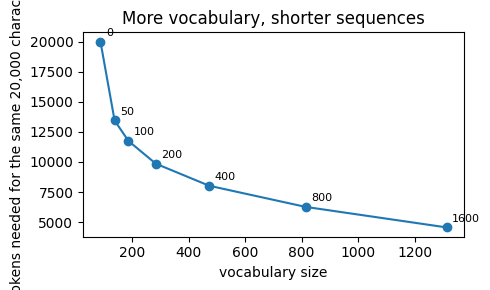

In [3]:
# The tradeoff the lecture draws: a larger vocabulary buys shorter sequences,
# and the return diminishes.
sample=text[:20000]
rows=[]
for m in [0,50,100,200,400,800,1600]:
    _,ws=train_bpe(sample,m)
    vocab=len({t for w in ws for t in w}); length=sum(len(w) for w in ws)
    rows.append((m,vocab,length))

fig,ax=plt.subplots(figsize=(5,3))
v=[r[1] for r in rows]; n=[r[2] for r in rows]
ax.plot(v,n,'o-')
for m,vv,ln in rows: ax.annotate(f'{m}',(vv,ln),textcoords='offset points',xytext=(4,4),fontsize=8)
ax.set_xlabel('vocabulary size'); ax.set_ylabel('tokens needed for the same 20,000 characters')
ax.set_title('More vocabulary, shorter sequences'); fig.tight_layout()
print(f'characters: {len(sample)}   |   no merges: {rows[0][2]} tokens   |   1600 merges: {rows[-1][2]} tokens')

## 2. The model as a black box

Before any architecture, fix the type signature. The model is a function

$$f_\theta:\ \{0,\dots,V-1\}^{B\times T}\ \longrightarrow\ \mathbb{R}^{B\times T\times V},$$

taking a batch of token *indices* to a batch of **logits** — one real number per
vocabulary entry per position. A logit is an unnormalized score: only after a
softmax is it a probability. Position $t$ scores the token that should come
*next*, so the targets are the inputs shifted by one.

Everything before the architecture section depends only on this signature.

In [4]:
B,T,V=2,5,len(chars)
logits=torch.randn(B,T,V)          # as if produced by an untrained model
targets=torch.randint(0,V,(B,T))   # the next token at each position

# The training loss, written the way it appears in every implementation.
loss=F.cross_entropy(logits.flatten(0,1),   # (B*T, V)
                     targets.flatten())     # (B*T,)

# cross_entropy is log_softmax followed by negative log likelihood, fused into a
# single function. Doing it in two steps gives the same number:
logp=torch.log_softmax(logits,dim=-1)
manual=-logp.gather(-1,targets.unsqueeze(-1)).mean()

print(f'F.cross_entropy      {loss.item():.6f}')
print(f'log_softmax + gather {manual.item():.6f}')
print(f'ln(V)                {math.log(V):.6f}  <- a model that predicts every token equally')
print()
print('Untrained random logits score WORSE than the uniform model: confident and')
print('wrong costs more than undecided. Training first has to reach ln(V).')

F.cross_entropy      5.342698
log_softmax + gather 5.342697
ln(V)                4.564348  <- a model that predicts every token equally

Untrained random logits score WORSE than the uniform model: confident and
wrong costs more than undecided. Training first has to reach ln(V).


In [5]:
# Why the softmax is never computed as written. exp(z) overflows in float32 at
# about z = 89; subtracting the row maximum changes nothing mathematically,
# because exp(z-m)/sum exp(z-m) = exp(z)/sum exp(z).
z=torch.tensor([1000.,1001.,1002.])
naive=torch.exp(z)/torch.exp(z).sum()
stable=torch.exp(z-z.max())/torch.exp(z-z.max()).sum()
print('naive :',naive.tolist(),'  <- overflow')
print('stable:',[round(x,6) for x in stable.tolist()],' == torch.softmax:',
      [round(x,6) for x in torch.softmax(z,0).tolist()])

naive : [nan, nan, nan]   <- overflow
stable: [0.090031, 0.244728, 0.665241]  == torch.softmax: [0.090031, 0.244728, 0.665241]


## 3. One causal-attention calculation, by hand
Scores are scaled, future entries receive negative infinity, rows are normalized, and weights average values.

In [6]:
def causal_attention(Q,K,V):
    scores=Q@K.transpose(-2,-1)/math.sqrt(Q.shape[-1])
    mask=torch.triu(torch.ones(scores.shape[-2:],dtype=torch.bool),diagonal=1)
    scores=scores.masked_fill(mask,float('-inf'))
    weights=torch.softmax(scores,dim=-1)
    return weights@V,weights

Q=torch.tensor([[1.,0.],[1.,1.],[0.,1.]])
K=torch.tensor([[1.,0.],[0.,1.],[1.,1.]])
V=torch.tensor([[4.,0.],[1.,2.],[0.,5.]])
output,weights=causal_attention(Q,K,V)
weights,output

(tensor([[1.0000, 0.0000, 0.0000],
         [0.5000, 0.5000, 0.0000],
         [0.1978, 0.4011, 0.4011]]),
 tensor([[4.0000, 0.0000],
         [2.5000, 1.0000],
         [1.1922, 2.8078]]))

## 4. A decoder block, and a model that trains
The implementation exposes QKV projections, head reshaping, causal masking, residual paths, layer normalization, and the token-wise MLP.

In [7]:
class CausalSelfAttention(nn.Module):
    def __init__(self,d_model=64,heads=4):
        super().__init__(); self.heads=heads; self.head_dim=d_model//heads
        self.qkv=nn.Linear(d_model,3*d_model); self.out=nn.Linear(d_model,d_model)
    def forward(self,x):
        B,T,D=x.shape
        q,k,v=self.qkv(x).chunk(3,dim=-1)
        def split(z): return z.view(B,T,self.heads,self.head_dim).transpose(1,2)
        q,k,v=map(split,(q,k,v))
        scores=q@k.transpose(-2,-1)/math.sqrt(self.head_dim)
        mask=torch.triu(torch.ones(T,T,dtype=torch.bool,device=x.device),diagonal=1)
        weights=torch.softmax(scores.masked_fill(mask,float('-inf')),dim=-1)
        mixed=(weights@v).transpose(1,2).contiguous().view(B,T,D)
        return self.out(mixed)

class Block(nn.Module):
    def __init__(self,d_model=64,heads=4):
        super().__init__(); self.ln1=nn.LayerNorm(d_model); self.attn=CausalSelfAttention(d_model,heads)
        self.ln2=nn.LayerNorm(d_model); self.mlp=nn.Sequential(nn.Linear(d_model,4*d_model),nn.GELU(),nn.Linear(4*d_model,d_model))
    def forward(self,x):
        x=x+self.attn(self.ln1(x)); return x+self.mlp(self.ln2(x))

class TinyLM(nn.Module):
    def __init__(self,vocab,context=64,d_model=64,layers=2):
        super().__init__(); self.context=context; self.token=nn.Embedding(vocab,d_model); self.position=nn.Embedding(context,d_model)
        self.blocks=nn.Sequential(*[Block(d_model,4) for _ in range(layers)]); self.norm=nn.LayerNorm(d_model); self.head=nn.Linear(d_model,vocab)
    def forward(self,index):
        T=index.shape[1]; h=self.token(index)+self.position(torch.arange(T,device=index.device)); return self.head(self.norm(self.blocks(h)))

model=TinyLM(len(chars)); sum(p.numel() for p in model.parameters())

116576

In [8]:
context=64
def batch(size=32):
    starts=torch.randint(0,len(data)-context-1,(size,))
    x=torch.stack([data[s:s+context] for s in starts]); y=torch.stack([data[s+1:s+context+1] for s in starts])
    return x,y

optimizer=torch.optim.AdamW(model.parameters(),lr=2e-3)
losses=[]
for step in range(600):
    x,y=batch(); logits=model(x); loss=F.cross_entropy(logits.reshape(-1,len(chars)),y.reshape(-1))
    optimizer.zero_grad(); loss.backward(); optimizer.step(); losses.append(loss.item())
losses[0],losses[-1]

(4.73080587387085, 1.8488305807113647)

## 5. The parameter budget

Where do the parameters actually sit? Count them from the shapes rather than
trusting `numel()`, then apply the same formula to a model nobody here can
load. For a decoder-only Transformer with vocabulary $V$, width $d$, $L$
layers, MLP hidden size $h$, and grouped-query attention with
$g$ key/value heads of dimension $d_{\text{head}}$:

$$\underbrace{Vd}_{\text{embedding}}\;+\;L\bigl(\underbrace{2d^2+2dgd_{\text{head}}}_{\text{attention}}+\underbrace{3dh}_{\text{MLP}}+2d\bigr)\;+\;\underbrace{Vd}_{\text{output head}}.$$

In [9]:
def transformer_params(V,d,L,hidden,heads,kv_heads,tied=False):
    head_dim=d//heads
    embedding=V*d
    attention=d*d + 2*d*(kv_heads*head_dim) + d*d      # Q, K, V, output
    mlp=3*d*hidden                                      # gate, up, down
    per_layer=attention+mlp+2*d                         # + two norms
    output_head=0 if tied else V*d
    return dict(embedding=embedding,per_layer=per_layer,all_layers=L*per_layer,
                output_head=output_head,
                total=embedding+L*per_layer+output_head+d)

# The formula above is for a Llama-style block (SwiGLU, three MLP matrices,
# grouped-query attention). The model built in section 4 is older in shape: a
# two-matrix MLP, no grouping, and learned position embeddings. Counting it
# needs its own arithmetic, done here from the layer shapes alone.
V_,d_,L_,ctx_=len(chars),64,2,64
by_hand=(V_*d_                      # token embedding
         + ctx_*d_                  # position embedding
         + L_*(3*d_*d_+3*d_         #   qkv projection
               + d_*d_+d_           #   output projection
               + 2*d_ + 2*d_        #   two LayerNorms
               + 4*d_*d_+4*d_       #   MLP up
               + 4*d_*d_+d_)        #   MLP down
         + 2*d_                     # final LayerNorm
         + V_*d_+V_)                # output head
actual=sum(q.numel() for q in model.parameters())
print(f'counted from the shapes: {by_hand:,}')
print(f'sum(p.numel())         : {actual:,}')
assert by_hand==actual, 'the arithmetic and the model disagree'
print('\nThe two agree, so the formula-based estimate for a model we cannot load is')
print('trustworthy in the same way.')


counted from the shapes: 116,576
sum(p.numel())         : 116,576

The two agree, so the formula-based estimate for a model we cannot load is
trustworthy in the same way.


In [10]:
# Llama-3-8B, from its published configuration.
p=transformer_params(V=128256,d=4096,L=32,hidden=14336,heads=32,kv_heads=8)
for k in ['embedding','per_layer','all_layers','output_head','total']:
    print(f'{k:12s} {p[k]:>15,}   {p[k]/1e9:6.3f} B')
print()
print('The name says 8B. The blocks alone are 6.98 B; the two vocabulary-sized')
print('matrices contribute 0.525 B each, which is why tying them is tempting.')

embedding        525,336,576    0.525 B
per_layer        218,112,000    0.218 B
all_layers     6,979,584,000    6.980 B
output_head      525,336,576    0.525 B
total          8,030,261,248    8.030 B

The name says 8B. The blocks alone are 6.98 B; the two vocabulary-sized
matrices contribute 0.525 B each, which is why tying them is tempting.


## 6. Scaling: loss against model size

The lecture asserts that loss falls as a power law in model size,

$$L(N)\;=\;E+\frac{A}{N^{\alpha}},$$

with $E$ the irreducible entropy of the text. Five models are trained here at
the same step count and the same data, and the curve is fitted to what comes
out. This takes about ninety seconds.

In [11]:
context=64
class ScaleBlock(nn.Module):
    def __init__(s,d,h):
        super().__init__(); s.h=h; s.hd=d//h
        s.ln1=nn.LayerNorm(d); s.qkv=nn.Linear(d,3*d); s.proj=nn.Linear(d,d)
        s.ln2=nn.LayerNorm(d); s.mlp=nn.Sequential(nn.Linear(d,4*d),nn.GELU(),nn.Linear(4*d,d))
    def forward(s,x):
        B,T,D=x.shape; q,k,v=s.qkv(s.ln1(x)).chunk(3,-1)
        shape=lambda z: z.view(B,T,s.h,s.hd).transpose(1,2)
        q,k,v=map(shape,(q,k,v))
        a=F.scaled_dot_product_attention(q,k,v,is_causal=True)
        x=x+s.proj(a.transpose(1,2).reshape(B,T,D))
        return x+s.mlp(s.ln2(x))

class ScaleLM(nn.Module):
    def __init__(s,d,L,h=4):
        super().__init__(); s.tok=nn.Embedding(len(chars),d); s.pos=nn.Embedding(context,d)
        s.blocks=nn.Sequential(*[ScaleBlock(d,h) for _ in range(L)])
        s.ln=nn.LayerNorm(d); s.head=nn.Linear(d,len(chars))
    def forward(s,i):
        x=s.tok(i)+s.pos(torch.arange(i.shape[1]))
        return s.head(s.ln(s.blocks(x)))

def sample_batch(src,n=32):
    start=torch.randint(0,len(src)-context-1,(n,))
    return (torch.stack([src[i:i+context] for i in start]),
            torch.stack([src[i+1:i+context+1] for i in start]))

@torch.no_grad()
def validation_loss(m,n=20):
    m.eval(); total=0.
    for _ in range(n):
        x,y=sample_batch(valid_data)
        total+=F.cross_entropy(m(x).flatten(0,1),y.flatten()).item()
    m.train(); return total/n

sizes=[(16,1),(32,2),(64,2),(96,3),(128,4)]
scaling=[]
for d,L in sizes:
    torch.manual_seed(0)
    m=ScaleLM(d,L); N=sum(q.numel() for q in m.parameters())
    opt=torch.optim.AdamW(m.parameters(),lr=3e-3)
    for _ in range(1000):
        x,y=sample_batch(train_data)
        loss=F.cross_entropy(m(x).flatten(0,1),y.flatten())
        opt.zero_grad(); loss.backward(); opt.step()
    scaling.append((d,L,N,validation_loss(m)))
    print(f'd={d:4d}  L={L}  N={N:>8,}  validation loss {scaling[-1][3]:.3f}')

d=  16  L=1  N=   7,504  validation loss 2.515


d=  32  L=2  N=  33,760  validation loss 2.159


d=  64  L=2  N= 116,576  validation loss 1.760


d=  96  L=3  N= 360,384  validation loss 1.757


d= 128  L=4  N= 826,208  validation loss 1.919


fitted irreducible loss E = 1.359 nats per character
fitted exponent      alpha = 0.310

The largest model (826,208 parameters) came in at 1.919, above the
fit's 1.632. It is not a failure of the power law: the corpus is
fixed at 82,122 characters, so the biggest model is the first one with
more capacity than this much data supports. Loss depends on N and D together,
which is exactly the observation Chinchilla is about.


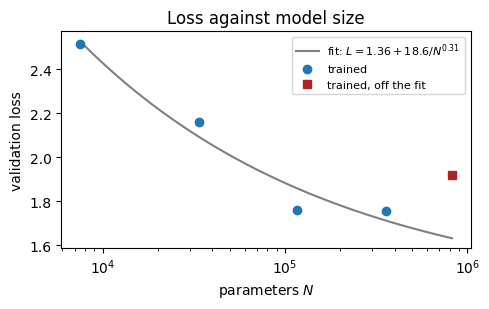

In [12]:
from scipy.optimize import curve_fit
N=np.array([r[2] for r in scaling],float); L_obs=np.array([r[3] for r in scaling])
power_law=lambda n,E,A,a: E+A/n**a

# Fit on the first four only: the largest model is discussed below.
(E,A,alpha),_=curve_fit(power_law,N[:4],L_obs[:4],p0=[1.,1e2,.3],maxfev=50000)

grid=np.logspace(np.log10(N[0]),np.log10(N[-1]),100)
fig,ax=plt.subplots(figsize=(5,3.2))
ax.plot(grid,power_law(grid,E,A,alpha),'-',color='0.5',
        label=fr'fit: $L={E:.2f}+{A:.3g}/N^{{{alpha:.2f}}}$')
ax.plot(N[:4],L_obs[:4],'o',label='trained')
ax.plot(N[4:],L_obs[4:],'s',color='firebrick',label='trained, off the fit')
ax.set_xscale('log'); ax.set_xlabel('parameters $N$'); ax.set_ylabel('validation loss')
ax.legend(fontsize=8); ax.set_title('Loss against model size'); fig.tight_layout()

print(f'fitted irreducible loss E = {E:.3f} nats per character')
print(f'fitted exponent      alpha = {alpha:.3f}')
print()
print(f'The largest model ({N[4]:,.0f} parameters) came in at {L_obs[4]:.3f}, above the')
print(f'fit\'s {power_law(N[4],E,A,alpha):.3f}. It is not a failure of the power law: the corpus is')
print(f'fixed at {len(text):,} characters, so the biggest model is the first one with')
print('more capacity than this much data supports. Loss depends on N and D together,')
print('which is exactly the observation Chinchilla is about.')

In [13]:
# Chinchilla, in closed form. Minimize L(N,D) = E + A/N^alpha + B/D^beta
# subject to the compute constraint C = 6ND. A Lagrange multiplier gives
#     N* proportional to C^{beta/(alpha+beta)},  D* proportional to C^{alpha/(alpha+beta)}.
a,b=0.34,0.28                                    # Hoffmann et al. (2022), Table 2
print(f'N* exponent {b/(a+b):.3f}   (paper reports 0.46)')
print(f'D* exponent {a/(a+b):.3f}   (paper reports 0.54)')
print()
print('Both near one half, so a doubled budget should roughly double BOTH the model')
print('and the data. The rule of thumb that follows is about 20 tokens per parameter.')
for N_ in [1e9,7e9,70e9]:
    D_=20*N_
    print(f'  N = {N_/1e9:5.1f} B  ->  D = {D_/1e9:6.0f} B tokens,  C = 6ND = {6*N_*D_:.2e} FLOPs')

N* exponent 0.452   (paper reports 0.46)
D* exponent 0.548   (paper reports 0.54)

Both near one half, so a doubled budget should roughly double BOTH the model
and the data. The rule of thumb that follows is about 20 tokens per parameter.
  N =   1.0 B  ->  D =     20 B tokens,  C = 6ND = 1.20e+20 FLOPs
  N =   7.0 B  ->  D =    140 B tokens,  C = 6ND = 5.88e+21 FLOPs
  N =  70.0 B  ->  D =   1400 B tokens,  C = 6ND = 5.88e+23 FLOPs


## 7. Generation, one token at a time
Training evaluated every target position in parallel. Generation appends one sampled character at a time.

In [14]:
@torch.no_grad()
def generate(prompt,length=400,temperature=.8):
    ids=torch.tensor([[stoi.get(c,stoi[' ']) for c in prompt]],dtype=torch.long)
    for _ in range(length):
        window=ids[:,-model.context:]; logits=model(window)[:,-1]/temperature
        next_id=torch.multinomial(torch.softmax(logits,dim=-1),1); ids=torch.cat([ids,next_id],dim=1)
    return ''.join(itos[i] for i in ids[0].tolist())
generate('## Machine learning',300)

'## Machine learning 2017, RL/435-midenent and detated the recture aNs chas or fe catur forse the lasoor a tre or or calste complises meathing Zearns chon stwe and lom for in thow -> Sline decew stap? `.\n\n#. — Pyntracted fictive decical se faatce, | reiths a ausicar codepres retentor the withould ine ere sormatuction -'